<a href="https://colab.research.google.com/github/FatimaZulfiqar02/intro-ml-course-winter2025/blob/main/ML_Datathon4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
mhealth_df = pd.read_csv('/content/Datathon #4 - mhealth Dataset - HAD7001.csv')
mhealth_df = mhealth_df[mhealth_df['Activity'] != 0]
mhealth_df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
6656,2.6493,-9.4517,0.37683,-0.20965,-0.88931,-0.50884,-2.8439,-9.0618,1.8177,-0.058824,-0.93429,-0.34483,1,subject1
6657,2.4157,-9.5306,0.40179,-0.20965,-0.88931,-0.50884,-2.9935,-9.2048,1.5189,-0.058824,-0.93429,-0.34483,1,subject1
6658,2.3865,-9.5991,0.48141,-0.20037,-0.86867,-0.50688,-2.8846,-9.1945,1.5507,-0.058824,-0.93429,-0.34483,1,subject1
6659,2.3758,-9.5997,0.42919,-0.20037,-0.86867,-0.50688,-2.9245,-9.1746,1.5413,-0.078431,-0.93429,-0.34052,1,subject1
6660,2.3239,-9.5406,0.40038,-0.20037,-0.86867,-0.50688,-2.8963,-9.2039,1.6127,-0.078431,-0.93429,-0.34052,1,subject1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def normalize_windows(X_train, X_val, X_test=None):
    """Normalize 3D window arrays (n_windows, seq_len, n_features) after train/test split.
    Fits StandardScaler on training data only, then transforms all splits."""
    n_feat = X_train.shape[2]
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(X_train.shape)
    X_val_norm = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
    if X_test is not None:
        X_test_norm = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)
        return X_train_norm, X_val_norm, X_test_norm, scaler
    return X_train_norm, X_val_norm, scaler


def preprocess_mhealth_data(df, window_size=100, overlap=10, subjects_to_exclude_from_oversampling=[8, 9]):
    # Remove rows with missing data
    df = df.dropna().reset_index(drop=True)

    # Feature Selection (12 sensor axes)
    feature_cols = ['alx', 'aly', 'alz', 'glx', 'gly', 'glz',
                    'arx', 'ary', 'arz', 'grx', 'gry', 'grz']

    # NOTE: Normalization is done AFTER train/test split using normalize_windows()

    # Windowing with Subject/Activity Integrity
    all_windows_meta = []
    step_size = window_size - overlap
    min_window = int(0.7 * window_size)  # Allow windows with at least 70% of window_size filled

    grouped = df.groupby(['subject', 'Activity'])

    for (subj_id, act_id), group in grouped:
        if len(group) < min_window:
            continue

        features = group[feature_cols].values
        for i in range(0, len(features) - min_window + 1, step_size):
            window = features[i : i + window_size]
            # Pad with zeros if partial window (near end of sequence)
            if len(window) < window_size:
                pad_length = window_size - len(window)
                window = np.pad(window, ((0, pad_length), (0, 0)), mode='constant', constant_values=0)
            all_windows_meta.append({
                'window': window,
                'activity': act_id,
                'subject': int(subj_id[7:])
            })

    if not all_windows_meta:
        return np.array([]), np.array([]), np.array([])

    temp_df = pd.DataFrame(all_windows_meta)

    print("\n--- Initial window counts per subject and activity ---")
    print(temp_df.groupby(['subject', 'activity']).size())
    print("----------------------------------------------------\n")

    loso_subjects_df = temp_df[~temp_df['subject'].isin(subjects_to_exclude_from_oversampling)]
    vault_subjects_df = temp_df[temp_df['subject'].isin(subjects_to_exclude_from_oversampling)]

    oversampled_windows = []
    oversampled_activities = []
    oversampled_subjects = []

    if not loso_subjects_df.empty:
        loso_window_counts = loso_subjects_df.groupby(['subject', 'activity']).size()
        max_windows_per_group_loso = loso_window_counts.max()

        for (subj_id, act_id), group_indices in loso_subjects_df.groupby(['subject', 'activity']).groups.items():
            current_group_windows = loso_subjects_df.loc[group_indices]
            num_current_windows = len(current_group_windows)

            if num_current_windows < max_windows_per_group_loso:
                num_to_add = max_windows_per_group_loso - num_current_windows
                if num_current_windows > 0:
                    duplicate_indices = np.random.choice(group_indices, size=num_to_add, replace=True)
                    duplicated_data = loso_subjects_df.loc[duplicate_indices]
                    current_group_windows = pd.concat([current_group_windows, duplicated_data])

            for _, row in current_group_windows.iterrows():
                oversampled_windows.append(row['window'])
                oversampled_activities.append(row['activity'])
                oversampled_subjects.append(row['subject'])

    for _, row in vault_subjects_df.iterrows():
        oversampled_windows.append(row['window'])
        oversampled_activities.append(row['activity'])
        oversampled_subjects.append(row['subject'])

    return np.array(oversampled_windows), np.array(oversampled_activities), np.array(oversampled_subjects)


# --- Generate datasets for window_size = 30 and 60 ---
print("=" * 60)
print("Preprocessing with window_size=30, overlap=30")
print("=" * 60)
X_30, y_raw_30, subj_labels_30 = preprocess_mhealth_data(mhealth_df, window_size=30, overlap=6)

print("=" * 60)
print("Preprocessing with window_size=60, overlap=10")
print("=" * 60)
X_60, y_raw_60, subj_labels_60 = preprocess_mhealth_data(mhealth_df, window_size=60, overlap=12)

# One-Hot Encode labels
encoder = OneHotEncoder(sparse_output=False)
y_30 = encoder.fit_transform(y_raw_30.reshape(-1, 1))
y_60 = encoder.fit_transform(y_raw_60.reshape(-1, 1))

print(f"\nWindow size 30 → X: {X_30.shape}, y: {y_30.shape}")
print(f"Window size 60 → X: {X_60.shape}, y: {y_60.shape}")

Preprocessing with window_size=30, overlap=30

--- Initial window counts per subject and activity ---
subject  activity
1        1           128
         2           128
         3           128
         4           128
         5           128
                    ... 
8        10          128
         11          128
         12           42
9        1           128
         2            34
Length: 98, dtype: int64
----------------------------------------------------

Preprocessing with window_size=60, overlap=10

--- Initial window counts per subject and activity ---
subject  activity
1        1           64
         2           64
         3           64
         4           64
         5           64
                     ..
8        10          64
         11          64
         12          21
9        1           64
         2           17
Length: 98, dtype: int64
----------------------------------------------------


Window size 30 → X: (13561, 30, 12), y: (13561, 12)
Window siz

### Categorizing Activities by Intensity

Based on the activity descriptions, categorized them into three intensity levels:

*   **Low Intensity**: 0 ('Nothing'), 1 ('Standing still'), 2 ('Sitting and relaxing'), 3 ('Lying down')
*   **Moderate Intensity**: 4 ('Walking'), 9 ('Cycling')
*   **High Intensity**: 5 ('Climbing stairs'), 6 ('Waist bends forward'), 7 ('Frontal elevation of arms'), 8 ('Knees bending (crouching)'), 10 ('Jogging'), 11 ('Running'), 12 ('Jump front & back')

In [ ]:
# Create intensity labels
def get_intensity_label(activity_id):
    low_intensity = [0, 1, 2, 3]
    moderate_intensity = [4, 9]
    high_intensity = [5, 6, 7, 8, 10, 11, 12]

    if activity_id in low_intensity:
        return 0
    elif activity_id in moderate_intensity:
        return 1
    elif activity_id in high_intensity:
        return 2
    else:
        return -1

intensity_encoder = OneHotEncoder(sparse_output=False)

# Window size 30
intensity_raw_30 = np.array([get_intensity_label(act_id) for act_id in y_raw_30])
y_intensity_30 = intensity_encoder.fit_transform(intensity_raw_30.reshape(-1, 1))

# Window size 60
intensity_raw_60 = np.array([get_intensity_label(act_id) for act_id in y_raw_60])
y_intensity_60 = intensity_encoder.fit_transform(intensity_raw_60.reshape(-1, 1))

print(f"Window 30 → Activity labels: {y_30.shape}, Intensity labels: {y_intensity_30.shape}")
print(f"Window 60 → Activity labels: {y_60.shape}, Intensity labels: {y_intensity_60.shape}")

Window 30 → Activity labels: (13561, 12), Intensity labels: (13561, 3)
Window 60 → Activity labels: (6738, 12), Intensity labels: (6738, 3)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import itertools


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## RNN

In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, output_dim=12, num_layers=2, dropout_prob=0.3):
        super(VanillaRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # RNN Layer with internal dropout (applied between layers)
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers,
                          batch_first=True,
                          dropout=dropout_prob if num_layers > 1 else 0)

        # Explicit Dropout layer before the fully connected head
        self.dropout = nn.Dropout(dropout_prob)

        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, features) -> (Batch, 100, 12)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)

        # Forward propagate RNN
        out, _ = self.rnn(x, h0)

        # Take the output of the last time step
        last_step_out = out[:, -1, :]

        # Apply dropout to the hidden representation
        dropout_out = self.dropout(last_step_out)

        # Final classification
        logits = self.fc(dropout_out)
        return logits

In [ ]:
def train_one_fold(model, train_loader, val_loader, epochs=10, lr=0.001, weight_decay=0.0001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_preds, val_true = [], []
        val_loss = 0
        with torch.no_grad():
            for vx, vy in val_loader:
                vx, vy = vx.to(device), vy.to(device)
                outputs = model(vx)
                loss_val = criterion(outputs, vy)
                val_loss += loss_val.item()
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(vy.cpu().numpy())

        val_acc = accuracy_score(val_true, val_preds)
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, '
              f'Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc

    return best_val_acc


# --- Hyperparameter Grid ---
param_grid = {
    'hidden_dim': [64, 128],
    'lr': [0.001],
    'weight_decay': [1e-4, 1e-3]
}

def run_full(X, y, subj_labels):
    loso_pool = [1, 2, 3, 4, 5, 6, 7]
    vault_subjects = [8, 9]
    num_classes = len(np.unique(y))

    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    best_overall_acc = 0.0
    best_params = None

    print(f"Starting Hyperparameter Search over {len(combinations)} combinations...")

    for params in combinations:
        fold_accuracies = []
        print(f"\nTesting Config: {params}")

        for val_subj in loso_pool:
            val_mask = (subj_labels == val_subj)
            train_mask = (np.isin(subj_labels, loso_pool)) & (subj_labels != val_subj)

            # Normalize after split: fit on train, transform val
            X_train_norm, X_val_norm, _ = normalize_windows(X[train_mask], X[val_mask])

            train_ds = TensorDataset(torch.FloatTensor(X_train_norm), torch.LongTensor(y[train_mask]))
            val_ds = TensorDataset(torch.FloatTensor(X_val_norm), torch.LongTensor(y[val_mask]))

            train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=64)

            model = VanillaRNN(input_dim=12,
                               hidden_dim=params['hidden_dim'],
                               output_dim=num_classes).to(device)

            fold_acc = train_one_fold(model, train_loader, val_loader,
                                      lr=params['lr'],
                                      weight_decay=params['weight_decay'])
            fold_accuracies.append(fold_acc)

        avg_loso_acc = np.mean(fold_accuracies)
        print(f"--> Mean LOSO Accuracy for this config: {avg_loso_acc:.4f}")

        if avg_loso_acc > best_overall_acc:
            best_overall_acc = avg_loso_acc
            best_params = params

    print(f"\n{'='*30}\nBEST PARAMETERS FOUND: {best_params}\nBest LOSO Acc: {best_overall_acc:.4f}\n{'='*30}")

    # --- Final Evaluation on the Vault (Subjects 8 & 9) ---
    print(f"\n>> FINAL EVALUATION: Training with Best Params on Subjects 1-7")
    vault_mask = np.isin(subj_labels, vault_subjects)
    loso_mask = np.isin(subj_labels, loso_pool)

    # Normalize: fit on full LOSO pool, transform vault
    X_train_norm, X_vault_norm, _ = normalize_windows(X[loso_mask], X[vault_mask])

    train_full_ds = TensorDataset(torch.FloatTensor(X_train_norm), torch.LongTensor(y[loso_mask]))
    vault_ds = TensorDataset(torch.FloatTensor(X_vault_norm), torch.LongTensor(y[vault_mask]))

    full_train_loader = DataLoader(train_full_ds, batch_size=64, shuffle=True)
    vault_loader = DataLoader(vault_ds, batch_size=64)

    final_model = VanillaRNN(input_dim=12,
                             hidden_dim=best_params['hidden_dim'],
                             output_dim=num_classes).to(device)

    _ = train_one_fold(final_model, full_train_loader, vault_loader,
                       epochs=15,
                       lr=best_params['lr'],
                       weight_decay=best_params['weight_decay'])

    final_model.eval()
    vault_preds, vault_true = [], []
    with torch.no_grad():
        for tx, ty in vault_loader:
            tx, ty = tx.to(device), ty.to(device)
            outputs = final_model(tx)
            _, predicted = torch.max(outputs, 1)
            vault_preds.extend(predicted.cpu().numpy())
            vault_true.extend(ty.cpu().numpy())

    print("\nFinal Test Classification Report (Subjects 8 & 9):")
    print(classification_report(vault_true, vault_preds))

    return best_overall_acc, best_params

### All Activities

In [ ]:
print("RNN - All Activities | Window size = 30")
print("=" * 60)
acc_rnn_30_all, params_rnn_30_all = run_full(X_30, np.argmax(y_30, axis=1), subj_labels_30)

print("\n" + "=" * 60)
print("RNN - All Activities | Window size = 60")
print("=" * 60)
acc_rnn_60_all, params_rnn_60_all = run_full(X_60, np.argmax(y_60, axis=1), subj_labels_60)

print("\n" + "=" * 60)
print("RNN ALL ACTIVITIES - WINDOW SIZE COMPARISON")
print("=" * 60)
print(f"  Window 30: Best LOSO acc = {acc_rnn_30_all:.4f} | Best params = {params_rnn_30_all}")
print(f"  Window 60: Best LOSO acc = {acc_rnn_60_all:.4f} | Best params = {params_rnn_60_all}")
best_window_rnn_all = 30 if acc_rnn_30_all >= acc_rnn_60_all else 60
print(f"  => Best window size: {best_window_rnn_all}")

RNN - All Activities | Window size = 30
Starting Hyperparameter Search over 4 combinations...

Testing Config: {'hidden_dim': 64, 'lr': 0.001, 'weight_decay': 0.0001}
Epoch [1/10], Train Loss: 1.4165, Val Loss: 1.2926, Val Acc: 0.4761
Epoch [2/10], Train Loss: 0.7754, Val Loss: 1.9702, Val Acc: 0.4639
Epoch [3/10], Train Loss: 0.6032, Val Loss: 1.8184, Val Acc: 0.5058
Epoch [4/10], Train Loss: 0.7541, Val Loss: 3.0523, Val Acc: 0.2494
Epoch [5/10], Train Loss: 0.8102, Val Loss: 2.0255, Val Acc: 0.4796
Epoch [6/10], Train Loss: 0.5999, Val Loss: 1.9876, Val Acc: 0.4971
Epoch [7/10], Train Loss: 0.4673, Val Loss: 2.2110, Val Acc: 0.4400
Epoch [8/10], Train Loss: 0.3886, Val Loss: 2.4884, Val Acc: 0.4516
Epoch [9/10], Train Loss: 0.3612, Val Loss: 2.4427, Val Acc: 0.4522
Epoch [10/10], Train Loss: 0.3574, Val Loss: 2.5255, Val Acc: 0.5291
Epoch [1/10], Train Loss: 1.4154, Val Loss: 1.6239, Val Acc: 0.4662
Epoch [2/10], Train Loss: 0.8847, Val Loss: 1.3054, Val Acc: 0.6381
Epoch [3/10], Tr

### Three Categories

In [ ]:
print("RNN - Three Intensity Categories | Window size = 30")
print("=" * 60)
acc_rnn_30_int, params_rnn_30_int = run_full(X_30, np.argmax(y_intensity_30, axis=1), subj_labels_30)

print("\n" + "=" * 60)
print("RNN - Three Intensity Categories | Window size = 60")
print("=" * 60)
acc_rnn_60_int, params_rnn_60_int = run_full(X_60, np.argmax(y_intensity_60, axis=1), subj_labels_60)

print("\n" + "=" * 60)
print("RNN INTENSITY CATEGORIES - WINDOW SIZE COMPARISON")
print("=" * 60)
print(f"  Window 30: Best LOSO acc = {acc_rnn_30_int:.4f} | Best params = {params_rnn_30_int}")
print(f"  Window 60: Best LOSO acc = {acc_rnn_60_int:.4f} | Best params = {params_rnn_60_int}")
best_window_rnn_int = 30 if acc_rnn_30_int >= acc_rnn_60_int else 60
print(f"  => Best window size: {best_window_rnn_int}")

RNN - Three Intensity Categories | Window size = 30
Starting Hyperparameter Search over 4 combinations...

Testing Config: {'hidden_dim': 64, 'lr': 0.001, 'weight_decay': 0.0001}
Epoch [1/10], Train Loss: 0.5427, Val Loss: 0.9640, Val Acc: 0.6142
Epoch [2/10], Train Loss: 0.2984, Val Loss: 0.9554, Val Acc: 0.7337
Epoch [3/10], Train Loss: 0.2940, Val Loss: 0.9468, Val Acc: 0.6929
Epoch [4/10], Train Loss: 0.2212, Val Loss: 0.8960, Val Acc: 0.7214
Epoch [5/10], Train Loss: 0.1791, Val Loss: 0.9042, Val Acc: 0.7756
Epoch [6/10], Train Loss: 0.1207, Val Loss: 0.4985, Val Acc: 0.8135
Epoch [7/10], Train Loss: 0.1203, Val Loss: 0.9263, Val Acc: 0.8089
Epoch [8/10], Train Loss: 0.0966, Val Loss: 1.3836, Val Acc: 0.7075
Epoch [9/10], Train Loss: 0.0902, Val Loss: 0.7965, Val Acc: 0.7541
Epoch [10/10], Train Loss: 0.1101, Val Loss: 0.6084, Val Acc: 0.7675
Epoch [1/10], Train Loss: 0.5152, Val Loss: 0.6791, Val Acc: 0.8328
Epoch [2/10], Train Loss: 0.3368, Val Loss: 0.6948, Val Acc: 0.8491
Epoc

## LSTM

In [ ]:
class HAR_LSTM(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, output_dim=12, num_layers=2, dropout_prob=0.3):
        super(HAR_LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                           batch_first=True,
                           dropout=dropout_prob if num_layers > 1 else 0)

        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)

        # Forward pass through LSTM
        out, _ = self.lstm(x, (h0, c0))

        # We use the output of the last time step for classification
        out = self.dropout(out[:, -1, :])
        logits = self.fc(out)
        return logits

In [ ]:
def train_and_validate(X, y, subj_labels, params):
    loso_pool = [1, 2, 3, 4, 5, 6, 7]
    fold_accuracies = []
    num_classes = len(np.unique(y))

    for val_subj in loso_pool:
        val_mask = (subj_labels == val_subj)
        train_mask = (np.isin(subj_labels, loso_pool)) & (subj_labels != val_subj)

        # Normalize after split: fit on train, transform val
        X_train_norm, X_val_norm, _ = normalize_windows(X[train_mask], X[val_mask])

        train_ds = TensorDataset(torch.FloatTensor(X_train_norm), torch.LongTensor(y[train_mask]))
        val_ds = TensorDataset(torch.FloatTensor(X_val_norm), torch.LongTensor(y[val_mask]))

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64)

        model = HAR_LSTM(hidden_dim=params['hidden_dim'],
                         dropout_prob=params['dropout'],
                         output_dim=num_classes).to(device)

        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=params.get('weight_decay', 0.0001))
        criterion = nn.CrossEntropyLoss()

        best_val_acc = 0
        for epoch in range(10):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad(); loss = criterion(model(bx), by); loss.backward(); optimizer.step()

            model.eval()
            preds, true = [], []
            with torch.no_grad():
                for vx, vy in val_loader:
                    vx, vy = vx.to(device), vy.to(device)
                    _, p = torch.max(model(vx), 1)
                    preds.extend(p.cpu().numpy()); true.extend(vy.cpu().numpy())

            acc = accuracy_score(true, preds)
            best_val_acc = max(best_val_acc, acc)

        fold_accuracies.append(best_val_acc)

    return np.mean(fold_accuracies)

In [ ]:
# --- Hyperparameter Search for LSTM - All Activities ---
search_space = [
    {'hidden_dim': 64, 'dropout': 0.3, 'weight_decay': 0.001},
    {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001},
]

print("LSTM - All Activities | Window size = 30")
best_score_30_all, best_params_30_all = 0, None
for params in search_space:
    print(f"  Testing params: {params}")
    score = train_and_validate(X_30, np.argmax(y_30, axis=1), subj_labels_30, params)
    print(f"  Mean LOSO acc: {score:.4f}")
    if score > best_score_30_all:
        best_score_30_all = score
        best_params_30_all = params

print("\nLSTM - All Activities | Window size = 60")
best_score_60_all, best_params_60_all = 0, None
for params in search_space:
    print(f"  Testing params: {params}")
    score = train_and_validate(X_60, np.argmax(y_60, axis=1), subj_labels_60, params)
    print(f"  Mean LOSO acc: {score:.4f}")
    if score > best_score_60_all:
        best_score_60_all = score
        best_params_60_all = params

print("\n" + "=" * 60)
print("LSTM ALL ACTIVITIES - WINDOW SIZE COMPARISON")
print("=" * 60)
print(f"  Window 30: Best LOSO acc = {best_score_30_all:.4f} | Params: {best_params_30_all}")
print(f"  Window 60: Best LOSO acc = {best_score_60_all:.4f} | Params: {best_params_60_all}")

best_window_lstm_all = 30 if best_score_30_all >= best_score_60_all else 60
best_params_lstm_all = best_params_30_all if best_window_lstm_all == 30 else best_params_60_all
X_lstm_all = X_30 if best_window_lstm_all == 30 else X_60
y_lstm_all = y_30 if best_window_lstm_all == 30 else y_60
subj_lstm_all = subj_labels_30 if best_window_lstm_all == 30 else subj_labels_60

print(f"  => Best window size for LSTM (All Activities): {best_window_lstm_all}")

LSTM - All Activities | Window size = 30
  Testing params: {'hidden_dim': 64, 'dropout': 0.3, 'weight_decay': 0.001}
  Mean LOSO acc: 0.6656
  Testing params: {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001}
  Mean LOSO acc: 0.6973

LSTM - All Activities | Window size = 60
  Testing params: {'hidden_dim': 64, 'dropout': 0.3, 'weight_decay': 0.001}
  Mean LOSO acc: 0.6960
  Testing params: {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001}
  Mean LOSO acc: 0.7316

LSTM ALL ACTIVITIES - WINDOW SIZE COMPARISON
  Window 30: Best LOSO acc = 0.6973 | Params: {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001}
  Window 60: Best LOSO acc = 0.7316 | Params: {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001}
  => Best window size for LSTM (All Activities): 60


### All Activities

In [ ]:
y_indices = np.argmax(y_lstm_all, axis=1)
num_classes = len(np.unique(y_indices))

test_mask  = np.isin(subj_lstm_all, [8, 9])
train_mask = np.isin(subj_lstm_all, [1, 2, 3, 4, 5, 6])
val_mask   = np.isin(subj_lstm_all, [7])

# Normalize after split: fit on train, transform val and test
X_train_norm, X_val_norm, X_test_norm, _ = normalize_windows(
    X_lstm_all[train_mask], X_lstm_all[val_mask], X_lstm_all[test_mask]
)

train_full_ds = TensorDataset(
    torch.from_numpy(X_train_norm.astype(np.float32)),
    torch.from_numpy(y_indices[train_mask].astype(np.int64))
)
val_full_ds = TensorDataset(
    torch.from_numpy(X_val_norm.astype(np.float32)),
    torch.from_numpy(y_indices[val_mask].astype(np.int64))
)
test_ds = TensorDataset(
    torch.from_numpy(X_test_norm.astype(np.float32)),
    torch.from_numpy(y_indices[test_mask].astype(np.int64))
)

full_train_loader = DataLoader(train_full_ds, batch_size=64, shuffle=True)
val_loader        = DataLoader(val_full_ds,   batch_size=64, shuffle=False)
test_loader       = DataLoader(test_ds,       batch_size=64, shuffle=False)

print(f"Using window_size={best_window_lstm_all} | Best params: {best_params_lstm_all}")
print(f"Train: {X_train_norm.shape}, Val: {X_val_norm.shape}, Test: {X_test_norm.shape}")

Using window_size=60 | Best params: {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001}
Train: (5112, 60, 12), Val: (852, 60, 12), Test: (774, 60, 12)


In [ ]:
final_model = HAR_LSTM(hidden_dim=best_params_lstm_all['hidden_dim'],
                       dropout_prob=best_params_lstm_all['dropout'],
                       output_dim=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=0.0005,
                       weight_decay=best_params_lstm_all['weight_decay'])
epochs = 15

In [ ]:
print(f"Starting Final Training on Subjects 1-7 using {device}...")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

patience = 3  # Number of epochs to wait for improvement
best_val_loss = float('inf')
counter = 0
best_model_state = None  # To save the best model weights

for epoch in range(epochs):
    final_model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for batch_x, batch_y in full_train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = final_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    train_epoch_loss = running_loss / len(full_train_loader)
    train_epoch_accuracy = 100 * correct_train / total_train
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    # Validation phase
    final_model.eval()  # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0
    with torch.no_grad():
        for batch_x_val, batch_y_val in val_loader: # Use val_loader for validation
            batch_x_val, batch_y_val = batch_x_val.to(device), batch_y_val.to(device)
            outputs_val = final_model(batch_x_val)
            loss_val = criterion(outputs_val, batch_y_val)
            val_running_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += batch_y_val.size(0)
            correct_val += (predicted_val == batch_y_val).sum().item()

    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_accuracy = 100 * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

    # Early Stopping Logic
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        counter = 0
        best_model_state = final_model.state_dict()  # Save best model state
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss for {patience} consecutive epochs.")
            break

    if (epoch + 1) % 3 == 0 or epoch == 0 or epoch == epochs -1:
        print(f'Epoch [{epoch+1}/{epochs}], ' \
              f'Train Loss: {train_epoch_loss:.4f}, ' \
              f'Train Acc: {train_epoch_accuracy:.2f}%, ' \
              f'Val Loss: {val_epoch_loss:.4f}, ' \
              f'Val Acc: {val_epoch_accuracy:.2f}%')

# Load the best model state if early stopping occurred
if best_model_state:
    final_model.load_state_dict(best_model_state)
    print("Loaded best model state from previous epoch.")

Starting Final Training on Subjects 1-7 using cuda...
Epoch [1/15], Train Loss: 2.0351, Train Acc: 32.79%, Val Loss: 2.4950, Val Acc: 25.23%
Epoch [3/15], Train Loss: 0.7885, Train Acc: 68.70%, Val Loss: 2.3594, Val Acc: 31.69%
Epoch [6/15], Train Loss: 0.4348, Train Acc: 83.82%, Val Loss: 2.5609, Val Acc: 51.53%
Early stopping triggered after 7 epochs due to no improvement in validation loss for 3 consecutive epochs.
Loaded best model state from previous epoch.


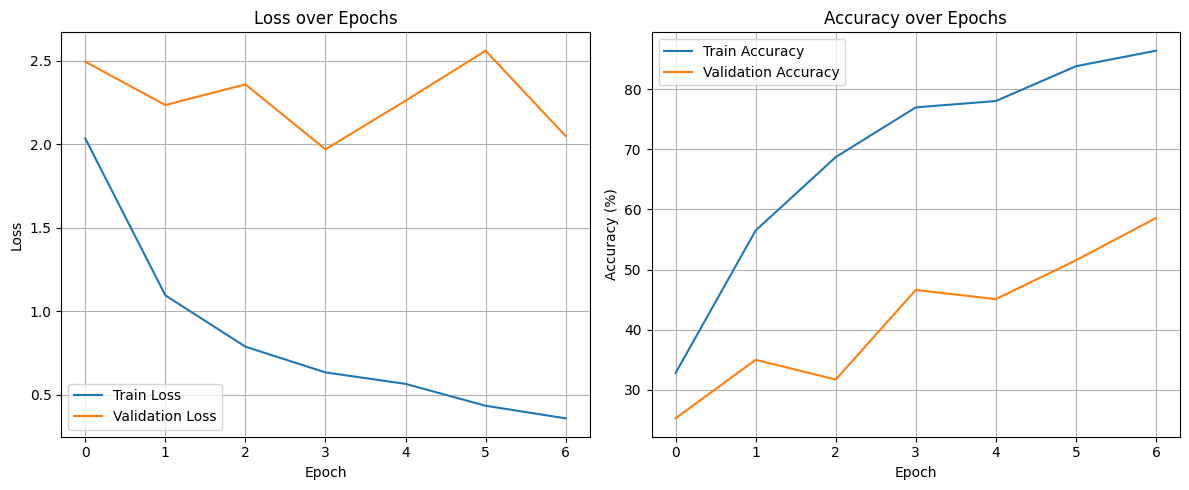

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Final Test Report on Subjects 8 & 9
print("\nTraining Complete. Evaluating on the Vault (Subjects 8 & 9)...")
final_model.eval()
v_preds, v_true = [], []

with torch.no_grad():
    for tx, ty in test_loader:
        tx, ty = tx.to(device), ty.to(device)

        outputs = final_model(tx)
        _, predicted = torch.max(outputs, 1)

        v_preds.extend(predicted.cpu().numpy())
        v_true.extend(ty.cpu().numpy())

# Output Final Metrics
print("\n" + "="*30)
print("FINAL TEST PERFORMANCE (UNSEEN PATIENTS)")
print("="*30)
print(classification_report(v_true, v_preds))


Training Complete. Evaluating on the Vault (Subjects 8 & 9)...

FINAL TEST PERFORMANCE (UNSEEN PATIENTS)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       128
           1       0.00      0.00      0.00        81
           2       1.00      1.00      1.00        64
           3       0.25      0.08      0.12        64
           4       0.33      0.89      0.48        64
           5       0.00      0.00      0.00        44
           6       0.60      0.40      0.48        63
           7       0.75      0.11      0.20        53
           8       0.85      0.73      0.79        64
           9       0.73      0.69      0.71        64
          10       0.71      0.75      0.73        64
          11       0.25      1.00      0.40        21

    accuracy                           0.41       774
   macro avg       0.46      0.47      0.41       774
weighted avg       0.43      0.41      0.38       774



### Three Categories

In [ ]:
y_indices = np.argmax(y_intensity_60, axis=1)
num_classes = len(np.unique(y_indices))

test_mask  = np.isin(subj_lstm_all, [8, 9])
train_mask = np.isin(subj_lstm_all, [1, 2, 3, 4, 5, 6])
val_mask   = np.isin(subj_lstm_all, [7])

# Normalize after split: fit on train, transform val and test
X_train_norm, X_val_norm, X_test_norm, _ = normalize_windows(
    X_lstm_all[train_mask], X_lstm_all[val_mask], X_lstm_all[test_mask]
)

train_full_ds = TensorDataset(
    torch.from_numpy(X_train_norm.astype(np.float32)),
    torch.from_numpy(y_indices[train_mask].astype(np.int64))
)
val_full_ds = TensorDataset(
    torch.from_numpy(X_val_norm.astype(np.float32)),
    torch.from_numpy(y_indices[val_mask].astype(np.int64))
)
test_ds = TensorDataset(
    torch.from_numpy(X_test_norm.astype(np.float32)),
    torch.from_numpy(y_indices[test_mask].astype(np.int64))
)

full_train_loader = DataLoader(train_full_ds, batch_size=64, shuffle=True)
val_loader        = DataLoader(val_full_ds,   batch_size=64, shuffle=False)
test_loader       = DataLoader(test_ds,       batch_size=64, shuffle=False)

print(f"Using window_size={best_window_lstm_all} | Best params: {best_params_lstm_all}")
print(f"Train: {X_train_norm.shape}, Val: {X_val_norm.shape}, Test: {X_test_norm.shape}")

Using window_size=60 | Best params: {'hidden_dim': 128, 'dropout': 0.5, 'weight_decay': 0.001}
Train: (5112, 60, 12), Val: (852, 60, 12), Test: (774, 60, 12)


In [ ]:
final_model = HAR_LSTM(hidden_dim=best_params_lstm_all['hidden_dim'],
                       dropout_prob=best_params_lstm_all['dropout'],
                       output_dim=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=0.0005,
                       weight_decay=best_params_lstm_all['weight_decay'])
epochs = 18

In [ ]:
print(f"Starting Final Training on Subjects 1-7 using {device}...")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

patience = 10  # Number of epochs to wait for improvement
best_val_loss = float('inf')
counter = 0
best_model_state = None  # To save the best model weights

for epoch in range(epochs):
    final_model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for batch_x, batch_y in full_train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = final_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    train_epoch_loss = running_loss / len(full_train_loader)
    train_epoch_accuracy = 100 * correct_train / total_train
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    # Validation phase
    final_model.eval()  # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0
    with torch.no_grad():
        for batch_x_val, batch_y_val in val_loader: # Use val_loader for validation
            batch_x_val, batch_y_val = batch_x_val.to(device), batch_y_val.to(device)
            outputs_val = final_model(batch_x_val)
            loss_val = criterion(outputs_val, batch_y_val)
            val_running_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += batch_y_val.size(0)
            correct_val += (predicted_val == batch_y_val).sum().item()

    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_accuracy = 100 * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

    # Early Stopping Logic
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        counter = 0
        best_model_state = final_model.state_dict()  # Save best model state
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss for {patience} consecutive epochs.")
            break

    if (epoch + 1) % 3 == 0 or epoch == 0 or epoch == epochs -1:
        print(f'Epoch [{epoch+1}/{epochs}], ' \
              f'Train Loss: {train_epoch_loss:.4f}, ' \
              f'Train Acc: {train_epoch_accuracy:.2f}%, ' \
              f'Val Loss: {val_epoch_loss:.4f}, ' \
              f'Val Acc: {val_epoch_accuracy:.2f}%')

# Load the best model state if early stopping occurred
if best_model_state:
    final_model.load_state_dict(best_model_state)
    print("Loaded best model state from previous epoch.")

Starting Final Training on Subjects 1-7 using cuda...
Epoch [1/18], Train Loss: 0.7169, Train Acc: 72.26%, Val Loss: 1.0934, Val Acc: 49.77%
Epoch [3/18], Train Loss: 0.2255, Train Acc: 91.47%, Val Loss: 1.0419, Val Acc: 68.43%
Epoch [6/18], Train Loss: 0.1155, Train Acc: 96.54%, Val Loss: 0.8562, Val Acc: 74.88%
Epoch [9/18], Train Loss: 0.2550, Train Acc: 88.58%, Val Loss: 1.2849, Val Acc: 65.61%
Epoch [12/18], Train Loss: 0.1153, Train Acc: 96.79%, Val Loss: 1.1084, Val Acc: 65.73%
Epoch [15/18], Train Loss: 0.3314, Train Acc: 89.30%, Val Loss: 0.7535, Val Acc: 78.76%
Epoch [18/18], Train Loss: 0.0411, Train Acc: 99.00%, Val Loss: 1.2454, Val Acc: 72.42%
Loaded best model state from previous epoch.


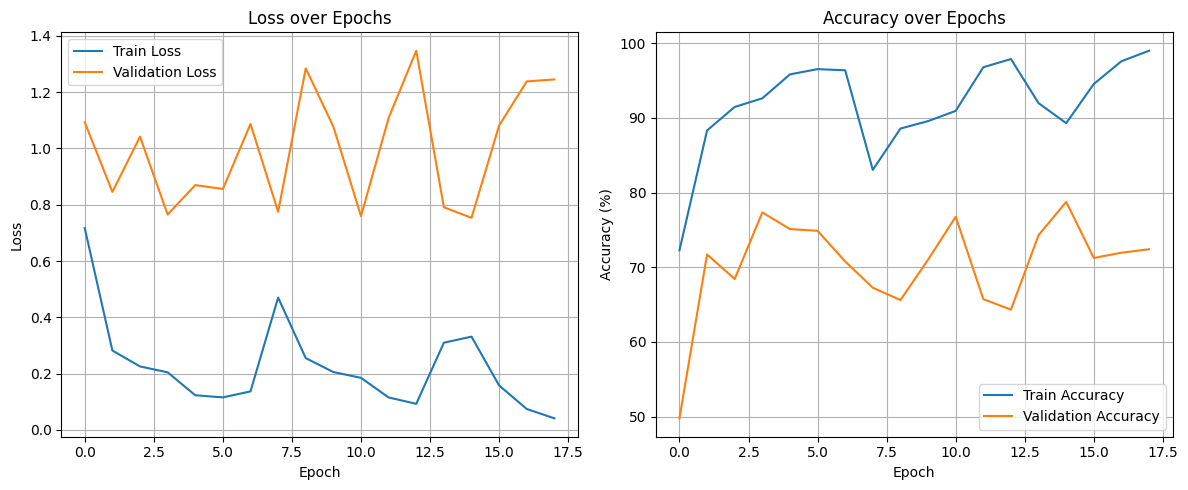

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Final Test Report on Subjects 8 & 9
print("\nTraining Complete. Evaluating on the Vault (Subjects 8 & 9)...")
final_model.eval()
v_preds, v_true = [], []

with torch.no_grad():
    for tx, ty in test_loader:
        tx, ty = tx.to(device), ty.to(device)

        outputs = final_model(tx)
        _, predicted = torch.max(outputs, 1)

        v_preds.extend(predicted.cpu().numpy())
        v_true.extend(ty.cpu().numpy())

# Output Final Metrics
print("\n" + "="*30)
print("FINAL TEST PERFORMANCE (UNSEEN PATIENTS)")
print("="*30)
print(classification_report(v_true, v_preds))


Training Complete. Evaluating on the Vault (Subjects 8 & 9)...

FINAL TEST PERFORMANCE (UNSEEN PATIENTS)
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       273
           1       0.97      0.30      0.46       128
           2       0.76      0.94      0.84       373

    accuracy                           0.77       774
   macro avg       0.83      0.67      0.69       774
weighted avg       0.80      0.77      0.75       774

